In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import os
import sys
import camb
import h5py
import healpy as hp
import numpy as np
from astropy import units as u
from ksw import KSW, Cosmology, Data, Shape
import logging

sys.path.append(os.path.join(os.getcwd(), "scripts"))
from utils import Config
from utils.plots import plot_ksw_predictions
from almgen import remove_mono_dipole

logging.getLogger("healpy").setLevel(logging.WARNING)

In [37]:
from joblib import Parallel, delayed

from ksw import utils, estimator_core

logger = logging.getLogger("KSW2")


def process_batch_step(
    tidx_start,
    theta_batch,
    thetas,
    theta_weights,
    lmax,
    dtype,
    rule,
    weights,
    f_i_ell,
    a_ell_m,
    grad_t,
    nphi,
):
    # side affects, needed and read only
    grad_t = grad_t.copy()

    thetas_batch = thetas[tidx_start : tidx_start + theta_batch]
    ct_weights_batch = theta_weights[tidx_start : tidx_start + theta_batch]
    y_m_ell = estimator_core.compute_ylm(thetas_batch, lmax, dtype=dtype)
    estimator_core.step(
        ct_weights_batch,
        rule,
        weights,
        f_i_ell.copy(),
        a_ell_m.copy(),
        y_m_ell,
        grad_t,
        nphi,
    )
    return grad_t


def process_batch_estimate(
    tidx_start,
    theta_batch,
    thetas,
    theta_weights,
    lmax,
    dtype,
    rule,
    weights,
    f_i_ell,
    a_ell_m,
    nphi,
):
    thetas_batch = thetas[tidx_start : tidx_start + theta_batch]
    ct_weights_batch = theta_weights[tidx_start : tidx_start + theta_batch]
    y_m_ell = estimator_core.compute_ylm(thetas_batch, lmax, dtype=dtype)
    return estimator_core.compute_estimate(
        ct_weights_batch, rule, weights, f_i_ell.copy(), a_ell_m.copy(), y_m_ell, nphi
    )


class KSW2(KSW):
    '''
    Jupyter doesnt like MPI, so this uses joblib to parallelize the loop
    '''
    def _step(self, alm, theta_batch=25):
        alm = utils.alm_return_2d(alm, self.npol, self.lmax)
        alm = self.icov(alm)
        a_ell_m = utils.alm2a_ell_m(alm)
        a_ell_m = a_ell_m.astype(self.cdtype)
        grad_t = np.zeros_like(a_ell_m)

        red_bisp = self.red_bispectra[0]
        f_i_ell, rule, weights = self._init_reduced_bispectrum(red_bisp)

        # Use joblib to parallelize the loop
        results = Parallel(n_jobs=-1, return_as="generator")(
            delayed(process_batch_step)(
                tidx_start,
                theta_batch,
                self.thetas,
                self.theta_weights,
                self.lmax,
                self.dtype,
                rule,
                weights,
                f_i_ell,
                a_ell_m,
                grad_t,
                self.nphi,
            )
            for tidx_start in range(0, len(self.thetas), theta_batch)
        )
        grad_t = sum(results)

        # Turn back into healpy shape.
        grad_t = utils.a_ell_m2alm(grad_t).astype(self.cdtype)
        return grad_t

    def _process_file_step(self, alm_loader, alm_file, **kwargs):
        logger.info(f"processing {alm_file}")
        alm = alm_loader(alm_file)
        grad_t = self._step(alm, **kwargs)
        mc_gt_sq = utils.contract_almxblm(grad_t, self.icov(self.beam(np.conj(grad_t))))
        return grad_t, mc_gt_sq

    def step_batch(self, alm_loader, alm_files, **kwargs):
        # Monte carlo quantities local to rank.
        mc_idx_loc = 0
        mc_gt_sq_loc = 0
        mc_gt_loc = 0

        # Combine the results
        for alm_file in alm_files:
            grad_t, mc_gt_sq = self._process_file_step(alm_loader, alm_file, **kwargs)

            mc_gt_loc += grad_t
            mc_gt_sq = utils.contract_almxblm(
                grad_t, self.icov(self.beam(np.conj(grad_t)))
            )
            mc_gt_sq_loc += mc_gt_sq
            mc_idx_loc += 1

        self.mc_gt = mc_gt_loc
        self.mc_gt_sq = mc_gt_sq_loc
        self.mc_idx = mc_idx_loc

    def compute_estimate_batch(self, alm_loader, alm_files, **kwargs):
        estimates = np.zeros(len(alm_files))
        fisher = kwargs.pop("fisher", self.compute_fisher())

        # Split alm_file loop over ranks.
        for aidx in range(len(alm_files)):
            alm_file = alm_files[aidx]
            alm = alm_loader(alm_file)

            estimate = self.compute_estimate(alm, fisher=fisher, **kwargs)
            logger.info("estimate : {}".format(estimate))

            estimates[aidx] = estimate

        return estimates

    def compute_estimate(self, alm, theta_batch=25, fisher=None, lin_term=None):
        # Similar to step, but only do backward transform, multiply alm with linear term
        # and apply normalization.

        alm = utils.alm_return_2d(alm, self.npol, self.lmax)
        alm = self.icov(alm)

        t_cubic = 0  # The cubic estimate.
        if fisher is None:
            fisher = self.compute_fisher()
        if lin_term is None:
            lin_term = self.compute_linear_term(alm, no_icov=True)

        a_ell_m = utils.alm2a_ell_m(alm)
        a_ell_m = a_ell_m.astype(self.cdtype)

        red_bisp = self.red_bispectra[0]
        f_i_ell, rule, weights = self._init_reduced_bispectrum(red_bisp)

        estimates = Parallel(n_jobs=-1, return_as="generator")(
            delayed(process_batch_estimate)(
                tidx_start,
                theta_batch,
                self.thetas,
                self.theta_weights,
                self.lmax,
                self.dtype,
                rule,
                weights,
                f_i_ell,
                a_ell_m,
                self.nphi,
            )
            for tidx_start in range(0, len(self.thetas), theta_batch)
        )

        t_cubic = sum(estimates)
        return (t_cubic - lin_term) / fisher

In [38]:
def beam(alm):
    return hp.sphtfunc.smoothalm(alm, fwhm=s.beam_width)

def compute_icov_ell(s, N, b):
    S_ell = cosmo._camb_data.get_cmb_power_spectra(
        cosmo.camb_params,
        lmax=s.lmax,
        spectra=["total"],
        CMB_unit="muK",
        raw_cl=True,
    )["total"][:, 0]
    b_inv = 1 / b
    return (1 / (S_ell + b_inv * N * b_inv))[None, :]
    
def get_fisher_iso(s, ksw):
    icov_ell = compute_icov_ell(s, s.noise_ell, s.beam_ell)
    fisher_iso = ksw.compute_fisher_isotropic(icov_ell)
    return fisher_iso, np.sqrt(1 / fisher_iso)

def setup_ksw(s):
    camb_params_obj = camb.set_params(**s.cosmo_params)
    cosmo = Cosmology(camb_params_obj)
    cosmo.compute_transfer(s.cosmo_params["max_l"])
    cosmo.compute_c_ell()

    # create the local shape
    loc_shape = Shape.prim_local(s.cosmo_params["ns"], s.cosmo_params["pivot_scalar"])
    cosmo.add_prim_reduced_bispectrum(loc_shape, s.radii)

    # setup the data and get our icov object
    data = Data(s.lmax, s.noise_ell, s.beam_ell, s.pols, cosmo)
    icov = data.icov_diag_lensed if s.lensing else data.icov_diag_nonlensed
    ksw = KSW2(cosmo.red_bispectra, icov, beam, s.lmax, s.pols)

    return ksw, data, icov

## Heidelberg

In [39]:
s = Config(["settings/heidelberg.json"])
ksw, data, icov = setup_ksw(s)

19-Mar-24 20:03:15 - utils.config - INFO - Loading settings from file settings/heidelberg.json
19-Mar-24 20:03:15 - utils.config - INFO - Running with settings: 
{
  "cosmo_params": {
    "As": 2.457e-09,
    "ns": 0.96,
    "pivot_scalar": 0.05,
    "max_l": 1500,
    "lmax": 1024,
    "H0": 70.1,
    "ombh2": 0.02256,
    "omch2": 0.1143,
    "tau": 0.084
  },
  "nsims": 1000,
  "fnl_range": [
    -1000,
    1000
  ],
  "nside": 512,
  "noise_scale_tt": 500,
  "beam_width": 10,
  "lensing": false
}
19-Mar-24 20:03:15 - utils.config - INFO - Base name: l1024_n512_ul_T_1000


In [40]:
get_fisher_iso(s, ksw)

(0.004751577, 14.507116956439294)

In [41]:
def alm_step_loader(idx):
    return data.compute_alm_sim(s.lensing)

thetas = int(np.floor(1.5 * s.lmax + 1))
ksw.step_batch(alm_step_loader, range(100), theta_batch=thetas // 32)
ksw_ran = True # dont need to do this later

19-Mar-24 20:05:33 - KSW2 - INFO - processing 0
19-Mar-24 20:06:14 - KSW2 - INFO - processing 1
19-Mar-24 20:06:39 - KSW2 - INFO - processing 2
19-Mar-24 20:07:01 - KSW2 - INFO - processing 3
19-Mar-24 20:07:23 - KSW2 - INFO - processing 4
19-Mar-24 20:07:46 - KSW2 - INFO - processing 5
19-Mar-24 20:08:07 - KSW2 - INFO - processing 6
19-Mar-24 20:08:32 - KSW2 - INFO - processing 7
19-Mar-24 20:08:57 - KSW2 - INFO - processing 8
19-Mar-24 20:09:22 - KSW2 - INFO - processing 9
19-Mar-24 20:09:48 - KSW2 - INFO - processing 10
19-Mar-24 20:10:13 - KSW2 - INFO - processing 11
19-Mar-24 20:10:39 - KSW2 - INFO - processing 12
19-Mar-24 20:11:05 - KSW2 - INFO - processing 13
19-Mar-24 20:11:28 - KSW2 - INFO - processing 14
19-Mar-24 20:11:54 - KSW2 - INFO - processing 15
19-Mar-24 20:12:17 - KSW2 - INFO - processing 16
19-Mar-24 20:12:44 - KSW2 - INFO - processing 17
19-Mar-24 20:13:08 - KSW2 - INFO - processing 18
19-Mar-24 20:13:34 - KSW2 - INFO - processing 19
19-Mar-24 20:14:00 - KSW2 - IN

In [42]:
fisher = float(ksw.compute_fisher())
fisher, np.sqrt(1 / fisher)

(0.010073082549173292, 9.963657803068083)

In [44]:
fnls = np.random.uniform(s.fnl_min, s.fnl_max, s.total_sims)
def alm_hei_loader(str_idx):
    idx = str(str_idx).zfill(4)
    t_scale = 2.7255 * 10 ** (6)

    base1 = f"data/heidelberg/alm_l_{idx}_v3.fits"
    base2 = f"data/heidelberg/alm_nl_{idx}_v3.fits"

    alm_heidelberg_l = np.array(hp.read_alm(base1, hdu=1))
    alm_heidelberg_nl = np.array(hp.read_alm(base2, hdu=1))
    alm_h_l = remove_mono_dipole(alm_heidelberg_l)
    alm_h_nl = remove_mono_dipole(alm_heidelberg_nl)
    fnl = fnls[int(idx)]

    logger.info("sending idx: %s, fnl: %s" % (idx, fnl))
    return (alm_h_l + fnl * alm_h_nl) * t_scale

idxs = range(1,51)
hei_estimates = ksw.compute_estimate_batch(alm_hei_loader, idxs, fisher=fisher)

19-Mar-24 20:48:51 - KSW2 - INFO - sending idx: 0001, fnl: 6.2844773597985295
19-Mar-24 20:49:03 - KSW2 - INFO - estimate : 0.34646857138094206
19-Mar-24 20:49:04 - KSW2 - INFO - sending idx: 0002, fnl: 863.8287118148589
19-Mar-24 20:49:15 - KSW2 - INFO - estimate : 715.3047703776385
19-Mar-24 20:49:15 - KSW2 - INFO - sending idx: 0003, fnl: -286.02928264452987
19-Mar-24 20:49:27 - KSW2 - INFO - estimate : -303.79294877126387
19-Mar-24 20:49:27 - KSW2 - INFO - sending idx: 0004, fnl: 832.6185564020511
19-Mar-24 20:49:39 - KSW2 - INFO - estimate : 830.7566690485062
19-Mar-24 20:49:40 - KSW2 - INFO - sending idx: 0005, fnl: -213.36999063908024
19-Mar-24 20:49:52 - KSW2 - INFO - estimate : -204.79202396058213
19-Mar-24 20:49:52 - KSW2 - INFO - sending idx: 0006, fnl: 156.336303007301
19-Mar-24 20:50:04 - KSW2 - INFO - estimate : 147.68204671310818
19-Mar-24 20:50:05 - KSW2 - INFO - sending idx: 0007, fnl: -309.470987327338
19-Mar-24 20:50:17 - KSW2 - INFO - estimate : -261.03089677205475


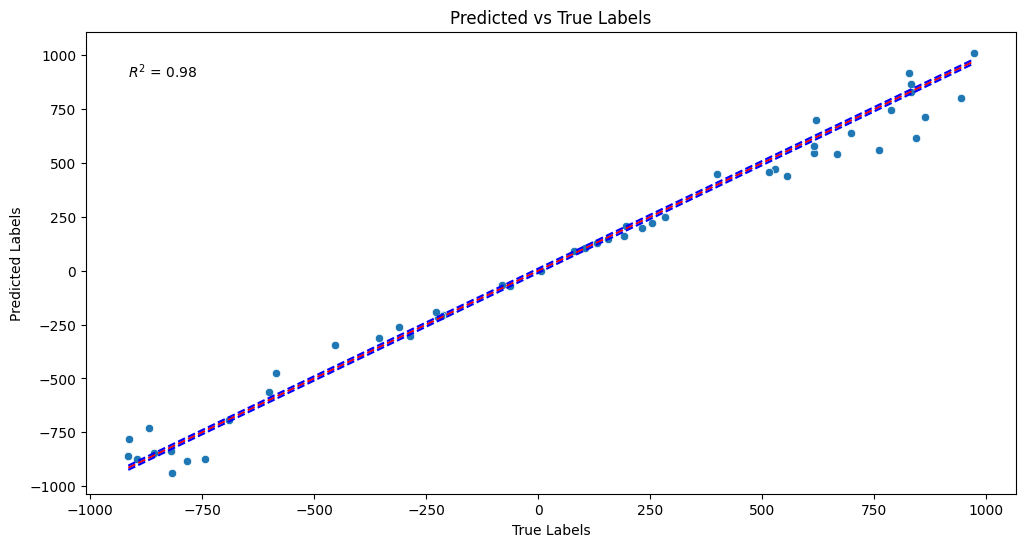

In [45]:
plot_ksw_predictions(fnls[idxs], hei_estimates, fisher)

## Sim

In [61]:
s = Config(
    [
        "settings/l500_n128.json",
        "--nsims", "200",
        "--narray", "500",
        "--lensing",
        "--noise"
    ]
)

ksw, data, icov = setup_ksw(s)

19-Mar-24 21:41:09 - utils.config - INFO - Loading settings from file settings/l500_n128.json
19-Mar-24 21:41:09 - utils.config - INFO - Running with settings: 
{
  "cosmo_params": {
    "As": 2.13e-09,
    "ns": 0.9624,
    "pivot_scalar": 0.05,
    "max_l": 1000,
    "lmax": 500,
    "H0": 67.5,
    "r": 0,
    "ombh2": 0.02233,
    "omch2": 0.1198,
    "mnu": 0.06,
    "tau": 0.0561,
    "TCMB": 2.7255,
    "lens_potential_accuracy": 2,
    "DoLateRadTruncation": false,
    "AccuracyBoost": 2.0,
    "lSampleBoost": 2.0,
    "lAccuracyBoost": 2.0
  },
  "nsims": 200,
  "narray": 500,
  "npatches": 10,
  "fnl_range": [
    -1000,
    1000
  ],
  "nside": 128,
  "lensing": true,
  "noise": true,
  "noise_scale_tt": 500,
  "noise_scale_ee": 1.41421,
  "noise_scale_te": 0,
  "beam_width": 10
}
19-Mar-24 21:41:09 - utils.config - INFO - Base name: l500_n128_l_T_100000
19-Mar-24 21:41:12 - root - WARNING - power_spectra_from_transfer with non-linear lensing does not recalculate the non-lin

In [62]:
get_fisher_iso(s, ksw)

(0.0017866279, 23.658267684286443)

In [63]:
def alm_step_loader(idx):
    return data.compute_alm_sim(s.lensing)

# if not ksw_ran:
thetas = int(np.floor(1.5 * s.lmax + 1))
ksw.step_batch(alm_step_loader, range(100), theta_batch=thetas // 32)

19-Mar-24 21:41:58 - KSW2 - INFO - processing 0
19-Mar-24 21:42:01 - KSW2 - INFO - processing 1
19-Mar-24 21:42:05 - KSW2 - INFO - processing 2
19-Mar-24 21:42:08 - KSW2 - INFO - processing 3
19-Mar-24 21:42:11 - KSW2 - INFO - processing 4
19-Mar-24 21:42:15 - KSW2 - INFO - processing 5
19-Mar-24 21:42:18 - KSW2 - INFO - processing 6
19-Mar-24 21:42:21 - KSW2 - INFO - processing 7
19-Mar-24 21:42:25 - KSW2 - INFO - processing 8
19-Mar-24 21:42:28 - KSW2 - INFO - processing 9
19-Mar-24 21:42:31 - KSW2 - INFO - processing 10
19-Mar-24 21:42:35 - KSW2 - INFO - processing 11
19-Mar-24 21:42:38 - KSW2 - INFO - processing 12
19-Mar-24 21:42:41 - KSW2 - INFO - processing 13
19-Mar-24 21:42:45 - KSW2 - INFO - processing 14
19-Mar-24 21:42:48 - KSW2 - INFO - processing 15
19-Mar-24 21:42:52 - KSW2 - INFO - processing 16
19-Mar-24 21:42:55 - KSW2 - INFO - processing 17
19-Mar-24 21:42:58 - KSW2 - INFO - processing 18
19-Mar-24 21:43:02 - KSW2 - INFO - processing 19
19-Mar-24 21:43:05 - KSW2 - IN

In [64]:
fisher = float(ksw.compute_fisher())
fisher, np.sqrt(1 / fisher)

(0.0033519058665276344, 17.27245592731339)

In [67]:
alm_file = h5py.File(s.alm_file, "r", swmr=True, locking=False)
alms = alm_file["alm"]
fnls = alm_file["fnl"]

def alm_sim_loader(str_idx):
    """Loads in a single alm given a int in string form. Used inside the KSW code."""
    idx, pol = np.unravel_index(int(str_idx), (s.nsims, s.npol))
    logger.info("sending idx: %s, pol: %s" % (idx, pol))
    alm = alms[idx,pol]
    logger.info("alm shape: %s" % (alm.shape,))
    return alm

idxs = range(50)
sim_estimates = ksw.compute_estimate_batch(alm_sim_loader, idxs, fisher=fisher)

19-Mar-24 21:49:24 - KSW2 - INFO - sending idx: 0, pol: 0
19-Mar-24 21:49:24 - KSW2 - INFO - alm shape: (125751,)
19-Mar-24 21:49:26 - KSW2 - INFO - estimate : -42538289.176339276
19-Mar-24 21:49:26 - KSW2 - INFO - sending idx: 1, pol: 0
19-Mar-24 21:49:26 - KSW2 - INFO - alm shape: (125751,)
19-Mar-24 21:49:28 - KSW2 - INFO - estimate : -4735344.433220667
19-Mar-24 21:49:28 - KSW2 - INFO - sending idx: 2, pol: 0
19-Mar-24 21:49:28 - KSW2 - INFO - alm shape: (125751,)
19-Mar-24 21:49:29 - KSW2 - INFO - estimate : 33106245.79629153
19-Mar-24 21:49:29 - KSW2 - INFO - sending idx: 3, pol: 0
19-Mar-24 21:49:29 - KSW2 - INFO - alm shape: (125751,)
19-Mar-24 21:49:31 - KSW2 - INFO - estimate : -4407190.720934761
19-Mar-24 21:49:31 - KSW2 - INFO - sending idx: 4, pol: 0
19-Mar-24 21:49:31 - KSW2 - INFO - alm shape: (125751,)
19-Mar-24 21:49:32 - KSW2 - INFO - estimate : -11052125.604430746
19-Mar-24 21:49:32 - KSW2 - INFO - sending idx: 5, pol: 0
19-Mar-24 21:49:32 - KSW2 - INFO - alm shape: 

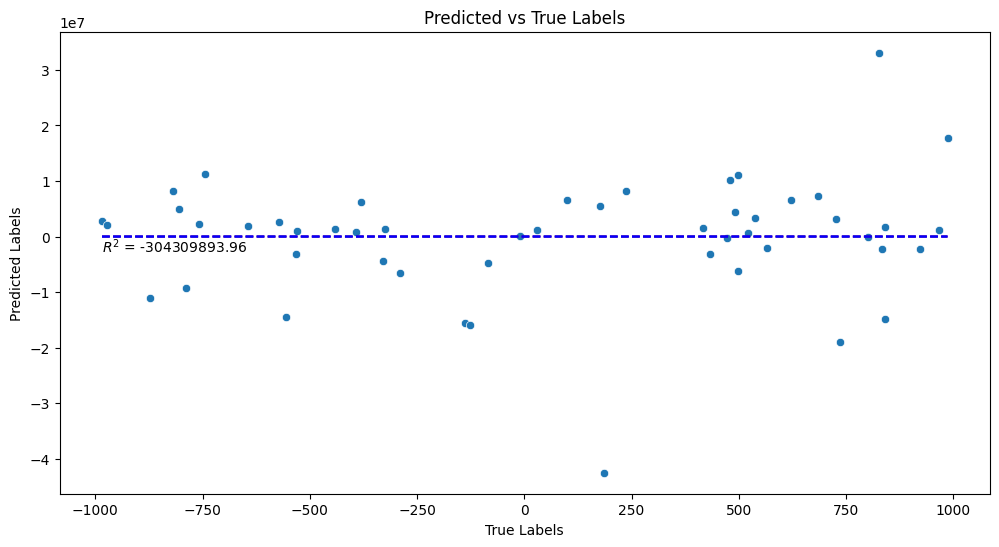

In [70]:
idx, pol = np.unravel_index(idxs, (s.nsims, s.npol))
plot_ksw_predictions(fnls[idx, 0], sim_estimates, fisher)